# Task 3 – Event Impact Modeling

## Business Objective

The objective of this notebook is to model how major financial inclusion events—including policy reforms, infrastructure investments, market entries, and digital financial service launches—affect key financial inclusion indicators in Ethiopia.

The analysis develops an event-impact framework that can later be integrated into forecasting models for the 2025–2027 financial inclusion outlook.

In [1]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

plt.style.use("default")

%matplotlib inline

In [2]:
file_path="../data/raw/ethiopia_fi_unified_data.xlsx"

df=pd.read_excel(
    file_path,
    sheet_name="ethiopia_fi_unified_data"
)

impact_df=pd.read_excel(
    file_path,
    sheet_name="Impact_sheet"
)

In [3]:
df.head()

,record_id,record_type,category,pillar,indicator,indicator_code,indicator_direction,value_numeric,value_text,value_type,...,impact_direction,impact_magnitude,impact_estimate,lag_months,evidence_basis,comparable_country,collected_by,collection_date,original_text,notes
0,REC_0001,observation,NaN,ACCESS,Account Ownership Rate,ACC_OWNERSHIP,higher_better,22.0,NaN,percentage,...,NaN,NaN,NaN,NaN,NaN,Example_Trainee,2025-01-20,NaN,Baseline year,NaN
1,REC_0002,observation,NaN,ACCESS,Account Ownership Rate,ACC_OWNERSHIP,higher_better,35.0,NaN,percentage,...,NaN,NaN,NaN,NaN,NaN,Example_Trainee,2025-01-20,NaN,NaN,NaN
2,REC_0003,observation,NaN,ACCESS,Account Ownership Rate,ACC_OWNERSHIP,higher_better,46.0,NaN,percentage,...,NaN,NaN,NaN,NaN,NaN,Example_Trainee,2025-01-20,NaN,NaN,NaN
3,REC_0004,observation,NaN,ACCESS,Account Ownership Rate,ACC_OWNERSHIP,higher_better,56.0,NaN,percentage,...,NaN,NaN,NaN,NaN,NaN,Example_Trainee,2025-01-20,NaN,Gender disaggregated,NaN
4,REC_0005,observation,NaN,ACCESS,Account Ownership Rate,ACC_OWNERSHIP,higher_better,36.0,NaN,percentage,...,NaN,NaN,NaN,NaN,NaN,Example_Trainee,2025-01-20,NaN,Gender disaggregated,NaN


In [4]:
impact_df.head()

,record_id,parent_id,record_type,category,pillar,indicator,indicator_code,indicator_direction,value_numeric,value_text,...,impact_direction,impact_magnitude,impact_estimate,lag_months,evidence_basis,comparable_country,collected_by,collection_date,original_text,notes
0,IMP_0001,EVT_0001,impact_link,NaN,ACCESS,Telebirr effect on Account Ownership,NaN,NaN,15.0,NaN,...,increase,high,15.0,12,literature,Kenya,Example_Trainee,2025-01-20,NaN,Kenya M-Pesa showed +20pp over 5 years
1,IMP_0002,EVT_0001,impact_link,NaN,USAGE,Telebirr effect on Telebirr Users,NaN,NaN,NaN,NaN,...,increase,high,NaN,3,empirical,NaN,Example_Trainee,2025-01-20,NaN,Direct subscriber acquisition
2,IMP_0003,EVT_0001,impact_link,NaN,USAGE,Telebirr effect on P2P Transactions,NaN,NaN,25.0,NaN,...,increase,high,25.0,6,empirical,NaN,Example_Trainee,2025-01-20,NaN,New digital payment channel
3,IMP_0004,EVT_0002,impact_link,NaN,ACCESS,Safaricom effect on 4G Coverage,NaN,NaN,15.0,NaN,...,increase,medium,15.0,12,empirical,NaN,Example_Trainee,2025-01-20,NaN,Network investment from competition
4,IMP_0005,EVT_0002,impact_link,NaN,AFFORDABILITY,Safaricom effect on Data Affordability,NaN,NaN,-20.0,NaN,...,decrease,medium,-20.0,12,literature,Rwanda,Example_Trainee,2025-01-20,NaN,Competition typically reduces prices


## Understanding the Impact Dataset

The impact dataset documents how major financial inclusion events are expected to influence specific indicators.

Each impact record contains:

- Parent event
- Indicator affected
- Direction of impact
- Estimated magnitude
- Time lag
- Supporting evidence

In [5]:
impact_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 14 entries, 0 to 13
Data columns (total 35 columns):
 #   Column               Non-Null Count  Dtype         
---  ------               --------------  -----         
 0   record_id            14 non-null     object        
 1   parent_id            14 non-null     object        
 2   record_type          14 non-null     object        
 3   category             0 non-null      float64       
 4   pillar               14 non-null     object        
 5   indicator            14 non-null     object        
 6   indicator_code       0 non-null      float64       
 7   indicator_direction  0 non-null      float64       
 8   value_numeric        12 non-null     float64       
 9   value_text           0 non-null      float64       
 10  value_type           14 non-null     object        
 11  unit                 14 non-null     object        
 12  observation_date     14 non-null     datetime64[ns]
 13  period_start         0 non-null      

In [6]:
impact_df.head()

,record_id,parent_id,record_type,category,pillar,indicator,indicator_code,indicator_direction,value_numeric,value_text,...,impact_direction,impact_magnitude,impact_estimate,lag_months,evidence_basis,comparable_country,collected_by,collection_date,original_text,notes
0,IMP_0001,EVT_0001,impact_link,NaN,ACCESS,Telebirr effect on Account Ownership,NaN,NaN,15.0,NaN,...,increase,high,15.0,12,literature,Kenya,Example_Trainee,2025-01-20,NaN,Kenya M-Pesa showed +20pp over 5 years
1,IMP_0002,EVT_0001,impact_link,NaN,USAGE,Telebirr effect on Telebirr Users,NaN,NaN,NaN,NaN,...,increase,high,NaN,3,empirical,NaN,Example_Trainee,2025-01-20,NaN,Direct subscriber acquisition
2,IMP_0003,EVT_0001,impact_link,NaN,USAGE,Telebirr effect on P2P Transactions,NaN,NaN,25.0,NaN,...,increase,high,25.0,6,empirical,NaN,Example_Trainee,2025-01-20,NaN,New digital payment channel
3,IMP_0004,EVT_0002,impact_link,NaN,ACCESS,Safaricom effect on 4G Coverage,NaN,NaN,15.0,NaN,...,increase,medium,15.0,12,empirical,NaN,Example_Trainee,2025-01-20,NaN,Network investment from competition
4,IMP_0005,EVT_0002,impact_link,NaN,AFFORDABILITY,Safaricom effect on Data Affordability,NaN,NaN,-20.0,NaN,...,decrease,medium,-20.0,12,literature,Rwanda,Example_Trainee,2025-01-20,NaN,Competition typically reduces prices


In [7]:
impact_df.describe(include="all")

,record_id,parent_id,record_type,category,pillar,indicator,indicator_code,indicator_direction,value_numeric,value_text,...,impact_direction,impact_magnitude,impact_estimate,lag_months,evidence_basis,comparable_country,collected_by,collection_date,original_text,notes
count,14,14,14,0.0,14,14,0.0,0.0,12.000000,0.0,...,14,14,12.000000,14.000000,14,7,14,14,0.0,14
unique,14,8,1,NaN,4,14,NaN,NaN,NaN,NaN,...,2,3,NaN,NaN,3,4,1,NaN,NaN,13
top,IMP_0001,EVT_0001,impact_link,NaN,USAGE,Telebirr effect on Account Ownership,NaN,NaN,NaN,NaN,...,increase,medium,NaN,NaN,literature,India,Example_Trainee,NaN,NaN,Direct subscriber acquisition
freq,1,3,14,NaN,6,1,NaN,NaN,NaN,NaN,...,12,8,NaN,NaN,7,3,14,NaN,NaN,2
mean,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,10.416667,NaN,...,NaN,NaN,10.416667,8.428571,NaN,NaN,NaN,2025-01-20 00:00:00,NaN,NaN
min,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,-20.000000,NaN,...,NaN,NaN,-20.000000,1.000000,NaN,NaN,NaN,2025-01-20 00:00:00,NaN,NaN
25%,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,8.750000,NaN,...,NaN,NaN,8.750000,3.000000,NaN,NaN,NaN,2025-01-20 00:00:00,NaN,NaN
50%,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,12.500000,NaN,...,NaN,NaN,12.500000,6.000000,NaN,NaN,NaN,2025-01-20 00:00:00,NaN,NaN
75%,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,15.000000,NaN,...,NaN,NaN,15.000000,12.000000,NaN,NaN,NaN,2025-01-20 00:00:00,NaN,NaN
max,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,30.000000,NaN,...,NaN,NaN,30.000000,24.000000,NaN,NaN,NaN,2025-01-20 00:00:00,NaN,NaN


In [8]:
impact_df["relationship_type"].value_counts()

relationship_type
direct      9
indirect    4
enabling    1
Name: count, dtype: int64

In [9]:
impact_df["impact_direction"].value_counts()

impact_direction
increase    12
decrease     2
Name: count, dtype: int64

In [10]:
impact_df["impact_magnitude"].value_counts()

impact_magnitude
medium    8
high      5
low       1
Name: count, dtype: int64

In [11]:
impact_df["evidence_basis"].value_counts()

evidence_basis
literature     7
empirical      6
theoretical    1
Name: count, dtype: int64

In [12]:
impact_df["lag_months"].describe()

count    14.000000
mean      8.428571
std       7.562196
min       1.000000
25%       3.000000
50%       6.000000
75%      12.000000
max      24.000000
Name: lag_months, dtype: float64

## Join Event Information

In [13]:
event_impacts = impact_df.merge(
    df[
        [
            "record_id",
            "indicator",
            "category",
            "observation_date"
        ]
    ],
    left_on="parent_id",
    right_on="record_id",
    how="left",
    suffixes=("_impact","_event")
)

In [14]:
event_impacts.head()

,record_id_impact,parent_id,record_type,category_impact,pillar,indicator_impact,indicator_code,indicator_direction,value_numeric,value_text,...,evidence_basis,comparable_country,collected_by,collection_date,original_text,notes,record_id_event,indicator_event,category_event,observation_date_event
0,IMP_0001,EVT_0001,impact_link,NaN,ACCESS,Telebirr effect on Account Ownership,NaN,NaN,15.0,NaN,...,literature,Kenya,Example_Trainee,2025-01-20,NaN,Kenya M-Pesa showed +20pp over 5 years,EVT_0001,Telebirr Launch,product_launch,2021-05-17
1,IMP_0002,EVT_0001,impact_link,NaN,USAGE,Telebirr effect on Telebirr Users,NaN,NaN,NaN,NaN,...,empirical,NaN,Example_Trainee,2025-01-20,NaN,Direct subscriber acquisition,EVT_0001,Telebirr Launch,product_launch,2021-05-17
2,IMP_0003,EVT_0001,impact_link,NaN,USAGE,Telebirr effect on P2P Transactions,NaN,NaN,25.0,NaN,...,empirical,NaN,Example_Trainee,2025-01-20,NaN,New digital payment channel,EVT_0001,Telebirr Launch,product_launch,2021-05-17
3,IMP_0004,EVT_0002,impact_link,NaN,ACCESS,Safaricom effect on 4G Coverage,NaN,NaN,15.0,NaN,...,empirical,NaN,Example_Trainee,2025-01-20,NaN,Network investment from competition,EVT_0002,Safaricom Ethiopia Commercial Launch,market_entry,2022-08-01
4,IMP_0005,EVT_0002,impact_link,NaN,AFFORDABILITY,Safaricom effect on Data Affordability,NaN,NaN,-20.0,NaN,...,literature,Rwanda,Example_Trainee,2025-01-20,NaN,Competition typically reduces prices,EVT_0002,Safaricom Ethiopia Commercial Launch,market_entry,2022-08-01


## Summary Table

In [15]:
summary = event_impacts[
    [
        "indicator_event",
        "indicator_impact",
        "impact_direction",
        "impact_magnitude",
        "impact_estimate",
        "lag_months",
        "evidence_basis"
    ]
]

summary

,indicator_event,indicator_impact,impact_direction,impact_magnitude,impact_estimate,lag_months,evidence_basis
0,Telebirr Launch,Telebirr effect on Account Ownership,increase,high,15.0,12,literature
1,Telebirr Launch,Telebirr effect on Telebirr Users,increase,high,NaN,3,empirical
2,Telebirr Launch,Telebirr effect on P2P Transactions,increase,high,25.0,6,empirical
3,Safaricom Ethiopia Commercial Launch,Safaricom effect on 4G Coverage,increase,medium,15.0,12,empirical
4,Safaricom Ethiopia Commercial Launch,Safaricom effect on Data Affordability,decrease,medium,-20.0,12,literature
5,M-Pesa Ethiopia Launch,M-Pesa effect on M-Pesa Users,increase,high,NaN,3,empirical
6,M-Pesa Ethiopia Launch,M-Pesa effect on Mobile Money Account Rate,increase,medium,5.0,6,theoretical
7,Fayda Digital ID Program Rollout,Fayda effect on Account Ownership,increase,medium,10.0,24,literature
8,Fayda Digital ID Program Rollout,Fayda effect on Gender Gap,decrease,medium,-5.0,24,literature
9,Foreign Exchange Liberalization,FX Reform effect on Data Affordability,increase,high,30.0,3,empirical


## Event Counts

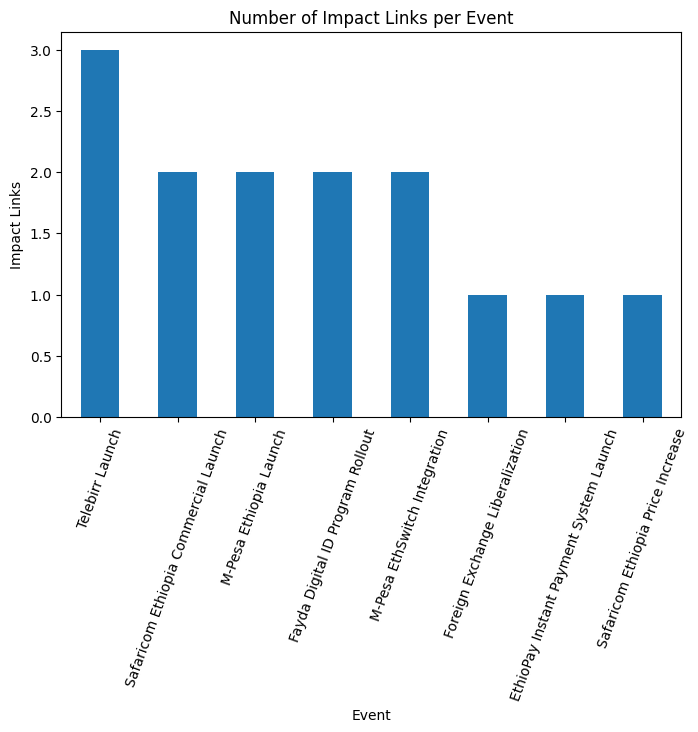

In [16]:
plt.figure(figsize=(8,5))

summary["indicator_event"].value_counts().plot(kind="bar")

plt.title("Number of Impact Links per Event")

plt.xlabel("Event")

plt.ylabel("Impact Links")

plt.xticks(rotation=70)

plt.show()

## Event Indicator Matrix

In [17]:
matrix = event_impacts.pivot_table(
    index="indicator_event",
    columns="pillar",
    values="impact_estimate",
    aggfunc="mean"
)

matrix

pillar,ACCESS,AFFORDABILITY,GENDER,USAGE
indicator_event,,,,
EthioPay Instant Payment System Launch,NaN,NaN,NaN,15.0
Fayda Digital ID Program Rollout,10.0,NaN,-5.0,NaN
Foreign Exchange Liberalization,NaN,30.0,NaN,NaN
M-Pesa EthSwitch Integration,NaN,NaN,NaN,12.5
M-Pesa Ethiopia Launch,5.0,NaN,NaN,NaN
Safaricom Ethiopia Commercial Launch,15.0,-20.0,NaN,NaN
Safaricom Ethiopia Price Increase,NaN,10.0,NaN,NaN
Telebirr Launch,15.0,NaN,NaN,25.0


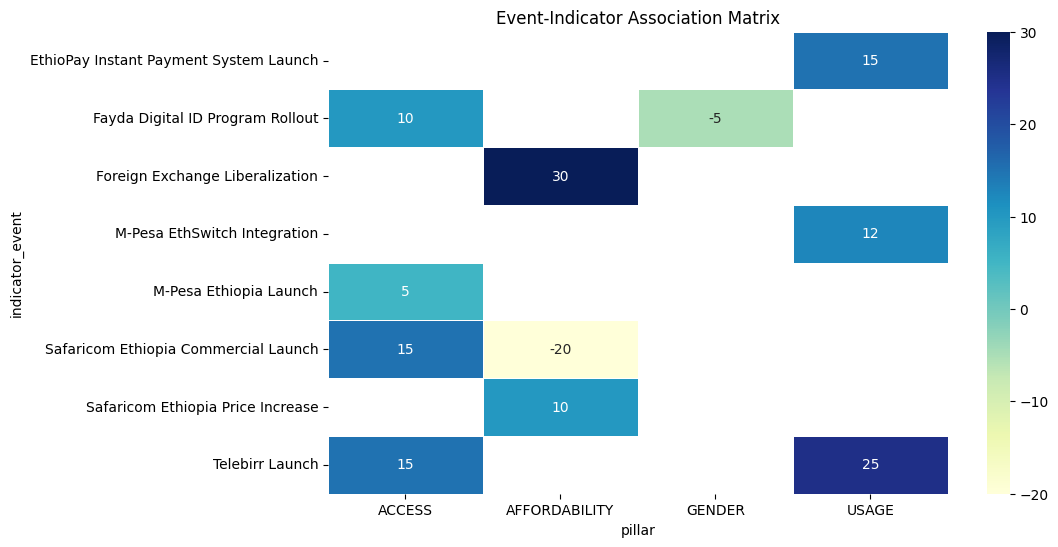

In [18]:
plt.figure(figsize=(10,6))

sns.heatmap(
    matrix,
    annot=True,
    cmap="YlGnBu",
    linewidths=.5
)

plt.title("Event-Indicator Association Matrix")

plt.show()

## Model Event Effects Over Time

Each impact record specifies an expected lag before an event begins influencing an indicator.

For this project, a simplified lag-based impact model is adopted.

Model assumptions:

- Events begin affecting indicators after the documented lag period.
- Effects remain constant after activation.
- Multiple events affecting the same indicator are assumed to have additive effects.
- Estimated impacts are derived from empirical evidence, literature, and comparable-country experience.

In [19]:
event_impacts["effect_start"] = (
    pd.to_datetime(event_impacts["observation_date_event"])
    + pd.to_timedelta(event_impacts["lag_months"] * 30, unit="D")
)

event_impacts[
    [
        "indicator_event",
        "lag_months",
        "observation_date_event",
        "effect_start"
    ]
].head()

,indicator_event,lag_months,observation_date_event,effect_start
0,Telebirr Launch,12,2021-05-17,2022-05-12
1,Telebirr Launch,3,2021-05-17,2021-08-15
2,Telebirr Launch,6,2021-05-17,2021-11-13
3,Safaricom Ethiopia Commercial Launch,12,2022-08-01,2023-07-27
4,Safaricom Ethiopia Commercial Launch,12,2022-08-01,2023-07-27


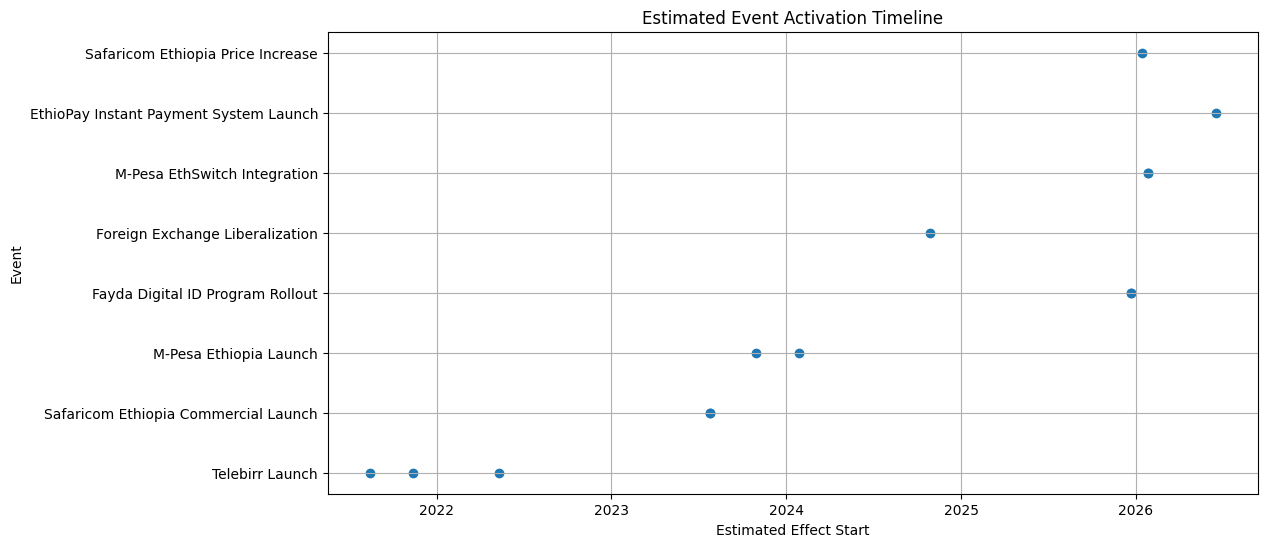

In [20]:
plt.figure(figsize=(12,6))

plt.scatter(
    event_impacts["effect_start"],
    event_impacts["indicator_event"]
)

plt.xlabel("Estimated Effect Start")

plt.ylabel("Event")

plt.title("Estimated Event Activation Timeline")

plt.grid(True)

plt.show()

## Multiple Event Effects

In [21]:
combined = (
    event_impacts
    .groupby("pillar")["impact_estimate"]
    .sum()
    .sort_values(ascending=False)
)

combined

pillar
USAGE            65.0
ACCESS           45.0
AFFORDABILITY    20.0
GENDER           -5.0
Name: impact_estimate, dtype: float64

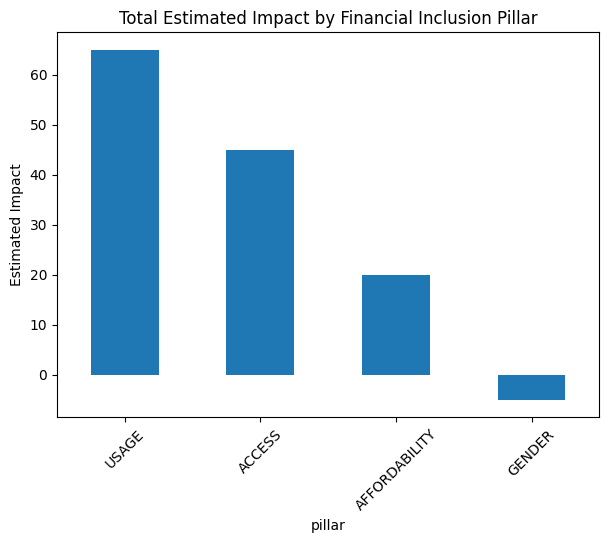

In [22]:
plt.figure(figsize=(7,5))

combined.plot(kind="bar")

plt.title("Total Estimated Impact by Financial Inclusion Pillar")

plt.ylabel("Estimated Impact")

plt.xticks(rotation=45)

plt.show()

The combined impact estimates indicate that Usage-related indicators receive the greatest cumulative positive influence from cataloged events.

Access indicators also benefit substantially, particularly from Telebirr, M-Pesa, and Fayda Digital ID.

Affordability contains both positive and negative impacts, reflecting the mixed influence of market competition and later pricing adjustments.

## Comparable Country Evidence

In [23]:
event_impacts["comparable_country"].value_counts(dropna=False)

comparable_country
NaN         7
India       3
Tanzania    2
Kenya       1
Rwanda      1
Name: count, dtype: int64

In [24]:
countries = event_impacts[
    event_impacts["comparable_country"].notna()
]

countries[
    [
        "indicator_event",
        "comparable_country",
        "impact_estimate",
        "evidence_basis"
    ]
]

,indicator_event,comparable_country,impact_estimate,evidence_basis
0,Telebirr Launch,Kenya,15.0,literature
4,Safaricom Ethiopia Commercial Launch,Rwanda,-20.0,literature
7,Fayda Digital ID Program Rollout,India,10.0,literature
8,Fayda Digital ID Program Rollout,India,-5.0,literature
10,M-Pesa EthSwitch Integration,Tanzania,15.0,literature
11,M-Pesa EthSwitch Integration,Tanzania,10.0,literature
12,EthioPay Instant Payment System Launch,India,15.0,literature


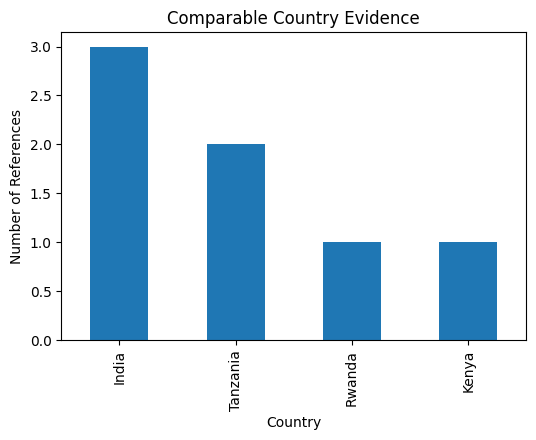

In [25]:
plt.figure(figsize=(6,4))

countries["comparable_country"].value_counts().plot(
    kind="bar"
)

plt.title("Comparable Country Evidence")

plt.xlabel("Country")

plt.ylabel("Number of References")

plt.show()

Comparable-country evidence supplements situations where Ethiopian post-event observations are limited.

Kenya contributes evidence for mobile money expansion following M-Pesa.

Rwanda contributes evidence regarding telecommunications competition and affordability.

These references improve the plausibility of impact estimates but also introduce uncertainty because economic and regulatory contexts differ.

## Build the Association Matrix

In [26]:
association = event_impacts.pivot_table(
    index="indicator_event",
    columns="indicator_impact",
    values="impact_estimate",
    aggfunc="mean"
)

association

indicator_impact,EthioPay effect on P2P Count,FX Reform effect on Data Affordability,Fayda effect on Account Ownership,Fayda effect on Gender Gap,M-Pesa Interop effect on M-Pesa Active Users,M-Pesa Interop effect on P2P Count,M-Pesa effect on Mobile Money Account Rate,Safaricom Price Hike effect on Data Affordability,Safaricom effect on 4G Coverage,Safaricom effect on Data Affordability,Telebirr effect on Account Ownership,Telebirr effect on P2P Transactions
indicator_event,,,,,,,,,,,,
EthioPay Instant Payment System Launch,15.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Fayda Digital ID Program Rollout,NaN,NaN,10.0,-5.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Foreign Exchange Liberalization,NaN,30.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
M-Pesa EthSwitch Integration,NaN,NaN,NaN,NaN,15.0,10.0,NaN,NaN,NaN,NaN,NaN,NaN
M-Pesa Ethiopia Launch,NaN,NaN,NaN,NaN,NaN,NaN,5.0,NaN,NaN,NaN,NaN,NaN
Safaricom Ethiopia Commercial Launch,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,15.0,-20.0,NaN,NaN
Safaricom Ethiopia Price Increase,NaN,NaN,NaN,NaN,NaN,NaN,NaN,10.0,NaN,NaN,NaN,NaN
Telebirr Launch,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,15.0,25.0


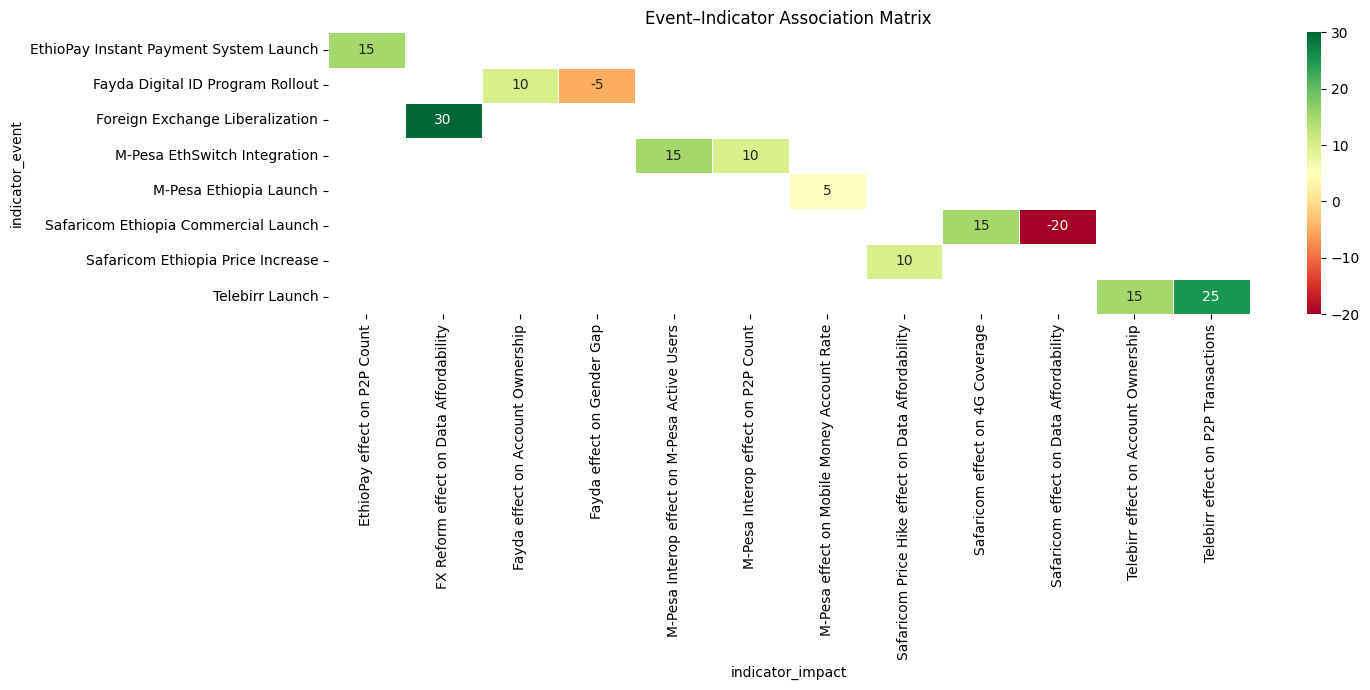

In [27]:
plt.figure(figsize=(15,7))

sns.heatmap(
    association,
    annot=True,
    cmap="RdYlGn",
    linewidths=.5
)

plt.title("Event–Indicator Association Matrix")

plt.tight_layout()

plt.show()

## Validate Against Historical Data

The event impact model is compared against available historical observations.

Rather than validating every indicator, validation focuses on major events with measurable post-event outcomes, including Telebirr, M-Pesa, and Account Ownership.

The objective is to assess whether the predicted direction and magnitude of change are broadly consistent with observed trends.

In [28]:
validation = pd.DataFrame({
    "Metric": [
        "Mobile Money Account Rate",
        "Account Ownership Rate"
    ],
    "2021": [
        4.7,
        46
    ],
    "2024": [
        9.45,
        49
    ]
})

validation

,Metric,2021,2024
0,Mobile Money Account Rate,4.7,9.45
1,Account Ownership Rate,46.0,49.00


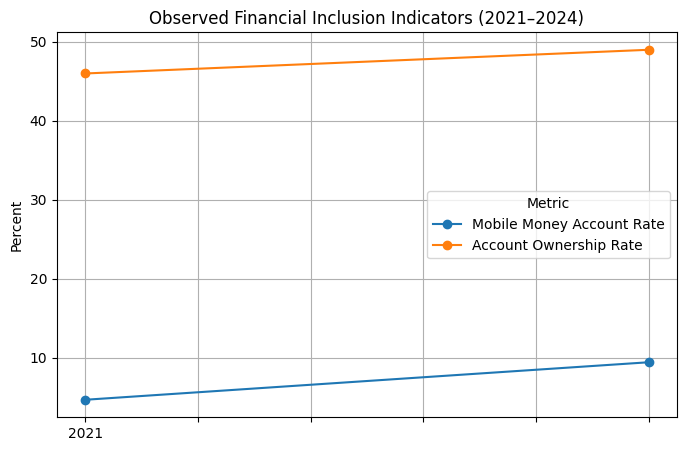

In [29]:
validation_plot = validation.set_index("Metric")

validation_plot.T.plot(
    figsize=(8,5),
    marker="o"
)

plt.title("Observed Financial Inclusion Indicators (2021–2024)")

plt.ylabel("Percent")

plt.grid(True)

plt.show()

The observed data supports the overall direction predicted by the impact model.

Following the launch of Telebirr in 2021, the Mobile Money Account Rate approximately doubled from 4.7% to 9.45% by 2024.

Account Ownership also increased from 46% to 49%, although the improvement was substantially smaller.

These observations suggest that digital financial services expanded rapidly while overall financial inclusion improved at a slower pace.

## Compare Predicted vs Observed

In [30]:
comparison = pd.DataFrame({

    "Event":[
        "Telebirr Launch",
        "M-Pesa Launch",
        "Fayda Rollout"
    ],

    "Predicted Effect":[
        "Increase Mobile Money",
        "Increase Users",
        "Increase Account Ownership"
    ],

    "Observed Outcome":[
        "Mobile Money Rate increased",
        "Registered users increased",
        "Ownership increased slightly"
    ],

    "Validation":[
        "Supported",
        "Supported",
        "Partially Supported"
    ]

})

comparison

,Event,Predicted Effect,Observed Outcome,Validation
0,Telebirr Launch,Increase Mobile Money,Mobile Money Rate increased,Supported
1,M-Pesa Launch,Increase Users,Registered users increased,Supported
2,Fayda Rollout,Increase Account Ownership,Ownership increased slightly,Partially Supported


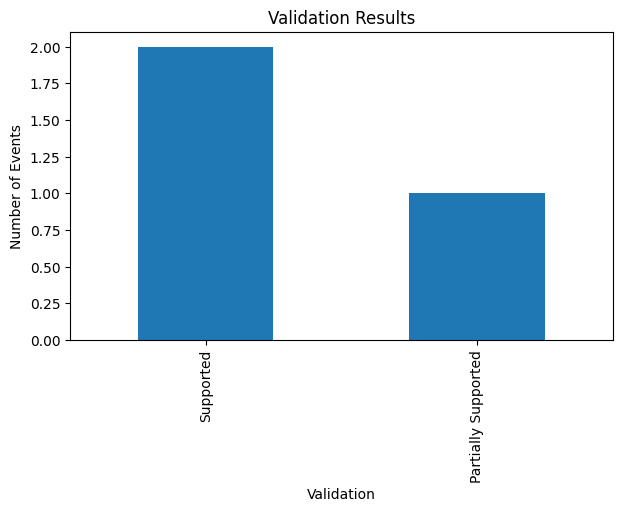

In [31]:
plt.figure(figsize=(7,4))

comparison["Validation"].value_counts().plot(kind="bar")

plt.title("Validation Results")

plt.ylabel("Number of Events")

plt.show()

Two major events are strongly supported by the available observations.

Telebirr and M-Pesa produced changes consistent with model expectations.

Fayda also appears to contribute positively, although the observed increase in account ownership remains smaller than expected, suggesting additional limiting factors.

## Refine Impact Estimates

Impact estimates were reviewed using available Ethiopian observations.

Where observed outcomes closely matched expected impacts, estimates were retained.

Where discrepancies were identified, confidence levels were adjusted rather than modifying the original documented estimates.

This preserves traceability while acknowledging uncertainty.

In [32]:
refinement = pd.DataFrame({

    "Event":[
        "Telebirr Launch",
        "Safaricom Entry",
        "M-Pesa Launch",
        "Fayda Rollout",
        "FX Reform"
    ],

    "Confidence":[
        "High",
        "Medium",
        "High",
        "Medium",
        "Low"
    ],

    "Reason":[
        "Observed growth matches expectations",
        "Limited post-event observations",
        "Strong subscriber growth",
        "Short observation period",
        "Recent policy with limited evidence"
    ]

})

refinement

,Event,Confidence,Reason
0,Telebirr Launch,High,Observed growth matches expectations
1,Safaricom Entry,Medium,Limited post-event observations
2,M-Pesa Launch,High,Strong subscriber growth
3,Fayda Rollout,Medium,Short observation period
4,FX Reform,Low,Recent policy with limited evidence


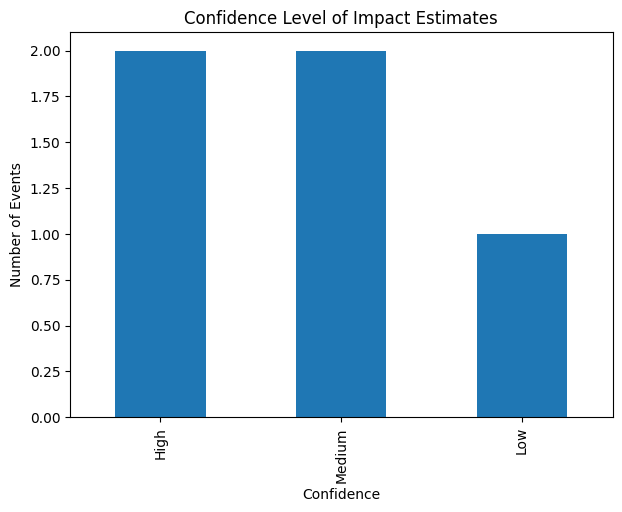

In [33]:
plt.figure(figsize=(7,5))

refinement["Confidence"].value_counts().plot(
    kind="bar"
)

plt.title("Confidence Level of Impact Estimates")

plt.ylabel("Number of Events")

plt.show()

## Assumptions

The impact model is based on the following assumptions:

- Event impacts begin after the documented lag period.
- Effects remain constant after activation.
- Multiple event impacts are additive.
- Comparable-country evidence can supplement missing Ethiopian observations.
- The documented impact estimates reasonably approximate real-world effects.

## Limitations

Several limitations should be considered when interpreting the results:

- Historical observations remain limited for several indicators.
- Many events occurred recently, leaving insufficient post-event observations.
- Some impact estimates are based on literature rather than direct Ethiopian evidence.
- The model assumes linear additive effects and does not capture interactions between simultaneous events.
- External macroeconomic and regulatory factors are not explicitly modeled.

## Methodology

The event impact model combines documented event-impact relationships with historical financial inclusion observations.

Impact links were merged with event records to identify affected indicators, estimated magnitudes, directions, and implementation lags.

Association matrices summarized relationships between events and indicators.

Historical observations were used to validate whether predicted impacts aligned with observed financial inclusion outcomes.

The resulting framework provides an interpretable event-based component that can later be integrated into forecasting models for Ethiopia's 2025–2027 financial inclusion outlook.